In [2]:
%%capture
%pip install qldpc

### Toric Code Memory Experiments

This tutorial runs small-scale memory experiments for the toric code:

- Build toric codes of distance `d`.
- Compile syndrome-measurement circuits using an edge-coloring schedule.
- Inject i.i.d. depolarizing noise of strength `p` on gates.
- Decode using BP+LSD + `sinter`.
- Sweep over `(d, p)` and estimate logical error rates for both Z- and X-basis memories.

What is a “memory experiment”? Prepare a logical state (e.g., `|0⟩_L` or `|+⟩_L`), perform `T` rounds of stabilizer measurements, then check if a logical flip occurred by the end. The resulting logical error rate as a function of the physical error rate lets you determine threshold-like behavior.

In [2]:
import os
from collections.abc import Sequence

import numpy as np
import sinter

from qldpc import codes
from qldpc.circuits import (
    DepolarizingNoiseModel,
    EdgeColoring,
    SinterDecoder,
    get_memory_experiment,
)
from qldpc.objects import Pauli, PauliXZ

#### Function: `run_experiments`

- **Inputs**:
  - **basis**: which logical memory to probe (`Pauli.Z` for Z-memory, `Pauli.X` for X-memory).
  - **distances**: code distances to sweep (controls lattice size and protection).
  - **error_rates**: physical depolarizing probabilities `p` to sweep.
- **What it does**:
  1. Creates a toric code of each distance `d`.
  2. Builds a syndrome-measurement circuit using `EdgeColoring()` (a schedule ensuring conflict-free checks).
  3. Adds a depolarizing noise model with probability `p` to gates.
  4. Wraps each configuration as a `sinter.Task` with metadata `{d, p}`.
  5. Runs batched Monte Carlo sampling with `sinter.collect` using the BP+LSD decoder (`SinterDecoder`).
- **Outputs**: a `sinter` stats object aggregating shots, errors, and metadata for downstream plotting.

In [3]:
def run_experiments(basis: PauliXZ, distances: Sequence[int], error_rates: Sequence[float]):
    sm_compiler = EdgeColoring()
    tasks: list[sinter.Task] = []
    for distance in distances:
        toric_code = codes.ToricCode(distance, rotated=False)
        for prob in error_rates:
            noise_model = DepolarizingNoiseModel(prob, include_idling_error=False)
            tasks.append(
                sinter.Task(
                    circuit=get_memory_experiment(
                        toric_code, sm_compiler, distance, basis, noise_model=noise_model
                    ),
                    json_metadata={"d": distance, "p": prob},
                )
            )

    return sinter.collect(
        num_workers=os.cpu_count() - 2,
        max_shots=10**6,
        max_errors=100,
        tasks=tasks,
        decoders=["bplsd"],
        custom_decoders={
            "bplsd": SinterDecoder(
                with_BP_LSD=True,
                max_iter=30,
                bp_method="ms",
                lsd_method="lsd_cs",
                lsd_order=0,
            )
        },
    )

#### Parameter sweep

Below, we define a small sweep:

- **distances**: `[3, 5, 7]` to show scaling behavior without heavy runtime.
- **error_rates**: `logspace(-3, -2, 5)` to cover 0.001–0.01.
- We run separate sweeps for **Z** and **X** bases to capture asymmetric behavior under the same physical noise model.


In [4]:
distances = [3, 5, 7]
error_rates = np.logspace(-3, -2, 5)
z_basis_results = run_experiments(Pauli.Z, distances, error_rates)
x_basis_results = run_experiments(Pauli.X, distances, error_rates)

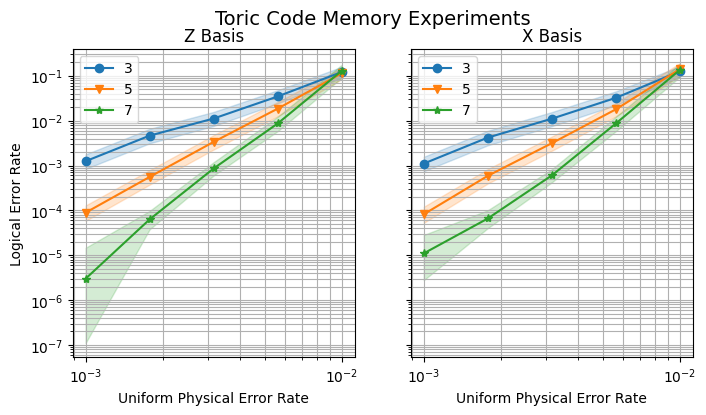

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, sharey=True, figsize=(8, 4))
sinter.plot_error_rate(
    ax=ax[0],
    stats=z_basis_results,
    x_func=lambda stats: stats.json_metadata["p"],
    group_func=lambda stats: stats.json_metadata["d"],
)
ax[0].loglog()
ax[0].grid(which="both")
ax[0].legend()
ax[0].set_ylabel("Logical Error Rate")
ax[0].set_xlabel("Uniform Physical Error Rate")
ax[0].set_title("Z Basis")

sinter.plot_error_rate(
    ax=ax[1],
    stats=x_basis_results,
    x_func=lambda stats: stats.json_metadata["p"],
    group_func=lambda stats: stats.json_metadata["d"],
)
ax[1].loglog()
ax[1].grid(which="both")
ax[1].legend()
ax[1].set_xlabel("Uniform Physical Error Rate")
ax[1].set_title("X Basis")

plt.suptitle("Toric Code Memory Experiments", fontsize=14)
plt.show()